## Installation des modules

In [1]:
%pip install ultralytics==8.3.0
%pip install gdown
%pip install --force-reinstall "numpy==1.26.4"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 881.3/881.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 re

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: Operation cancelled by user
^C


### Restart kernel after installation
This ensures the new NumPy build is loaded cleanly.


## Verification de l'env

In [6]:
import numpy as np

print("NumPy version:", np.__version__)


NumPy version: 1.26.4


#Disabling des warnings non nécéssaires

In [ ]:
import os

os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

## Préparation de l'environnement drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import json
BASE_DATASET = "/content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/SpaceAnimal"

print (os.listdir(BASE_DATASET))

['Drosophila', 'Zebrafish', 'C.elegans']


## Investigation Primaire

In [4]:
print(" ANALYSE COMPLÈTE DU DATASET SPACEANIMAL\n")
print(f"Chemin de base : {BASE_DATASET}\n")

species_list = ["C.elegans", "Drosophila", "Zebrafish"]

for species in species_list:
    species_path = os.path.join(BASE_DATASET, species)
    if not os.path.exists(species_path):
        print(f" Dossier {species} non trouvé !")
        continue

    ann_path = os.path.join(species_path, "annotations")
    if not os.path.exists(ann_path):
        print(f" Dossier annotations manquant pour {species}")
        continue

    # Recherche automatique des fichiers *_train.json et *_val.json
    train_json = None
    val_json = None
    for f in os.listdir(ann_path):
        if f.endswith("_train.json") or f.endswith("train.json"):
            train_json = os.path.join(ann_path, f)
        elif f.endswith("_val.json") or f.endswith("val.json"):
            val_json = os.path.join(ann_path, f)

    if not train_json or not val_json:
        print(f"JSON train/val non trouvés pour {species}")
        continue

    # Lecture des JSON
    train_images = train_inst = val_images = val_inst = 0
    kpt_per_animal = 0

    # Train
    with open(train_json, 'r') as f:
        data = json.load(f)
        train_images = len(data.get('images', []))
        train_inst = len(data.get('annotations', []))
        if train_inst > 0:
            kpt_per_animal = len(data['annotations'][0]['keypoints']) // 3

    # Val
    with open(val_json, 'r') as f:
        data = json.load(f)
        val_images = len(data.get('images', []))
        val_inst = len(data.get('annotations', []))

    total_images = train_images + val_images
    total_inst = train_inst + val_inst

    print(f" {species.upper():12} → {total_images:4d} images totales "
          f"({train_images:3d} train + {val_images:3d} val)")
    print(f"          Instances     : {total_inst:4d} ({train_inst:3d} train + {val_inst:3d} val)")
    print(f"          Keypoints par animal : {kpt_per_animal}")
    print(f"          JSON train    : {os.path.basename(train_json)}")
    print(f"          JSON val      : {os.path.basename(val_json)}")
    print("-" * 85)

 ANALYSE COMPLÈTE DU DATASET SPACEANIMAL

Chemin de base : /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/SpaceAnimal

 C.ELEGANS    → 6996 images totales (5622 train + 1374 val)
          Instances     : 15378 (12349 train + 3029 val)
          Keypoints par animal : 5
          JSON train    : worm_train.json
          JSON val      : worm_val.json
-------------------------------------------------------------------------------------
 DROSOPHILA   →  410 images totales (328 train +  82 val)
          Instances     : 4386 (3310 train + 1076 val)
          Keypoints par animal : 26
          JSON train    : drosophila_train.json
          JSON val      : drosophila_val.json
-------------------------------------------------------------------------------------
 ZEBRAFISH    →  560 images totales (448 train + 112 val)
          Instances     : 2237 (1790 train + 447 val)
          Keypoints par animal : 10
          JSON train    : zebrafish_train.json
          JSON val      :

==> On va travailler sur  C.ELEGANS

# Conversion COCO → YOLO-pose

YOLO-pose accepte id = 0

In [18]:
import json
import os
import shutil

# Self-contained COCO -> YOLO-pose conversion to avoid converter path bugs.
BASE = "/content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/SpaceAnimal"
TRAIN_JSON = f"{BASE}/C.elegans/annotations/worm_train.json"
VAL_JSON = f"{BASE}/C.elegans/annotations/worm_val.json"
SOURCE_ROOT = os.path.dirname(os.path.dirname(TRAIN_JSON))

OUTPUT_DATASET = "/content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/dataset_c.elegans_yolo"

In [19]:
import json

with open(TRAIN_JSON) as f:
    data = json.load(f)

print(data["annotations"][0].keys())
print(len(data["annotations"][0]["keypoints"]))

dict_keys(['num_keypoints', 'iscrowd', 'keypoints', 'image_id', 'bbox', 'area', 'category_id', 'id', 'worm_id'])
15


In [20]:
print(data["categories"])

[{'supercategory': 'worm', 'id': 1, 'name': 'worm', 'keypoints': ['head', 'front', 'middle', 'back', 'tail'], 'skeleton': [[1, 2], [2, 3], [3, 4], [4, 5]]}]


In [21]:
import json

def fix_categories(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Fix category id
    for cat in data["categories"]:
        cat["id"] = 0

    # Fix annotations category_id
    for ann in data["annotations"]:
        ann["category_id"] = 0

    # Save
    fixed_path = json_path.replace(".json", "_fixed.json")
    with open(fixed_path, "w") as f:
        json.dump(data, f)

    return fixed_path

In [22]:
TRAIN_JSON_FIXED = fix_categories(TRAIN_JSON)
VAL_JSON_FIXED   = fix_categories(VAL_JSON)

In [23]:
import json

with open(TRAIN_JSON_FIXED) as f:
    data = json.load(f)

print(data["categories"])

[{'supercategory': 'worm', 'id': 0, 'name': 'worm', 'keypoints': ['head', 'front', 'middle', 'back', 'tail'], 'skeleton': [[1, 2], [2, 3], [3, 4], [4, 5]]}]


## Creation dataset valable pour entrainement

In [24]:
import json
import os
import shutil

In [25]:
def unique_dir(path):
    candidate = path
    index = 2
    while os.path.exists(candidate):
        candidate = f"{path}{index}"
        index += 1
    os.makedirs(candidate, exist_ok=True)
    return candidate

In [26]:
def build_image_index(root_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    index = {}
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if os.path.splitext(filename)[1].lower() not in image_extensions:
                continue
            full_path = os.path.join(dirpath, filename)
            rel_path = os.path.relpath(full_path, root_dir).replace("\\", "/")
            index[rel_path] = full_path
            index[filename] = full_path
    return index

In [27]:
def resolve_image_path(image_index, file_name):
    normalized = file_name.replace("\\", "/")
    candidates = [normalized, os.path.basename(normalized)]
    for candidate in candidates:
        if candidate in image_index:
            return image_index[candidate]
    return None

In [28]:
def coco_to_yolo_pose(json_path, source_root, target_root):
    with open(json_path, "r") as file_handle:
        data = json.load(file_handle)

    image_index = build_image_index(source_root)
    images = {image["id"]: image for image in data.get("images", [])}
    annotations_by_image = {}
    for annotation in data.get("annotations", []):
        annotations_by_image.setdefault(annotation["image_id"], []).append(annotation)

    category_ids = sorted({category["id"] for category in data.get("categories", [])})
    category_map = {category_id: index for index, category_id in enumerate(category_ids)}

    images_dir = os.path.join(target_root, "images")
    labels_dir = os.path.join(target_root, "labels")
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    for image_id, image in images.items():
        source_image_path = resolve_image_path(image_index, image["file_name"])
        if source_image_path is None:
            raise FileNotFoundError(f"Image not found for {image['file_name']} in {source_root}")

        relative_image_path = image["file_name"].replace("\\", "/")
        destination_image_path = os.path.join(images_dir, relative_image_path)
        os.makedirs(os.path.dirname(destination_image_path), exist_ok=True)
        shutil.copy2(source_image_path, destination_image_path)

        label_path = os.path.join(labels_dir, os.path.splitext(relative_image_path)[0] + ".txt")
        os.makedirs(os.path.dirname(label_path), exist_ok=True)

        lines = []
        for annotation in annotations_by_image.get(image_id, []):
            if annotation.get("iscrowd", 0):
                continue
            bbox = annotation.get("bbox")
            if not bbox:
                continue
            x, y, width, height = bbox
            if width <= 0 or height <= 0:
                continue

            image_width = image["width"]
            image_height = image["height"]
            x_center = (x + width / 2) / image_width
            y_center = (y + height / 2) / image_height
            width_norm = width / image_width
            height_norm = height / image_height
            class_id = category_map.get(annotation.get("category_id"), 0)

            values = [class_id, x_center, y_center, width_norm, height_norm]
            keypoints = annotation.get("keypoints", [])
            for keypoint_index in range(0, len(keypoints), 3):
                keypoint_x, keypoint_y, visibility = keypoints[keypoint_index:keypoint_index + 3]
                values.extend([keypoint_x / image_width, keypoint_y / image_height, visibility])

            formatted_values = [str(values[0])] + [f"{value:.6f}" if isinstance(value, float) else str(value) for value in values[1:]]
            lines.append(" ".join(formatted_values))

        with open(label_path, "w") as file_handle:
            file_handle.write("\n".join(lines))

In [29]:
train_output = unique_dir(os.path.join(OUTPUT_DATASET, "train_yolo_pose"))
val_output = unique_dir(os.path.join(OUTPUT_DATASET, "val_yolo_pose"))

In [30]:
print(" Conversion train.json ...")
coco_to_yolo_pose(TRAIN_JSON, SOURCE_ROOT, train_output)

print(" Conversion val.json ...")
coco_to_yolo_pose(VAL_JSON, SOURCE_ROOT, val_output)

print(" Conversion terminée !")
print(" Train:", train_output)
print(" Val  :", val_output)

 Conversion train.json ...
 Conversion val.json ...
 Conversion terminée !
 Train: /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/dataset_c.elegans_yolo/train_yolo_pose2
 Val  : /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/dataset_c.elegans_yolo/val_yolo_pose2


lasted 32min

In [31]:
import os
from pathlib import Path

train_root = Path(train_output)
val_root = Path(val_output)

def check_split(root):
    images_dir = root / "images"
    labels_dir = root / "labels"

    image_files = sorted([p for p in images_dir.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}])
    label_files = sorted(labels_dir.rglob("*.txt"))

    print(f"\n{root.name}")
    print("images:", len(image_files))
    print("labels:", len(label_files))
    print("images dir exists:", images_dir.exists())
    print("labels dir exists:", labels_dir.exists())

    missing_labels = []
    for img in image_files[:10]:
        rel = img.relative_to(images_dir).with_suffix(".txt")
        label = labels_dir / rel
        if not label.exists():
            missing_labels.append(str(rel))

    if missing_labels:
        print("missing label examples:", missing_labels[:5])
    else:
        print("first 10 images all have matching labels")

    if label_files:
        sample = label_files[0].read_text().strip().splitlines()
        print("sample label file:", label_files[0])
        print("first line:", sample[0] if sample else "<empty>")
        if sample:
            parts = sample[0].split()
            print("values per line:", len(parts))
            print("class id:", parts[0])
            print("bbox values normalized:", all(0 <= float(x) <= 1 for x in parts[1:5]))

check_split(train_root)
check_split(val_root)


train_yolo_pose2
images: 5622
labels: 5622
images dir exists: True
labels dir exists: True
first 10 images all have matching labels
sample label file: /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/dataset_c.elegans_yolo/train_yolo_pose2/labels/002/002_000.txt
first line: 0 0.683418 0.181991 0.309245 0.276693 0.836914 0.148438 2 0.755859 0.110352 2 0.633789 0.081055 2 0.561523 0.173828 2 0.686523 0.303711 2
values per line: 20
class id: 0
bbox values normalized: True

val_yolo_pose2
images: 1374
labels: 1374
images dir exists: True
labels dir exists: True
first 10 images all have matching labels
sample label file: /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/dataset_c.elegans_yolo/val_yolo_pose2/labels/001/001_000.txt
first line: 0 0.344835 0.576497 0.158420 0.460069 0.269531 0.352539 2 0.291992 0.444336 2 0.333008 0.535156 2 0.411133 0.633789 2 0.386719 0.799805 2
values per line: 20
class id: 0
bbox values normalized: True


In [32]:
import random
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

In [33]:
def load_yolo_pose_sample(image_root, label_path):
    image_path = image_root / label_path.relative_to(label_path.parents[1]).with_suffix(".jpg")
    if not image_path.exists():
        for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            candidate = image_path.with_suffix(ext)
            if candidate.exists():
                image_path = candidate
                break
    return image_path


In [34]:
def draw_sample(image_root, label_path):
    image_path = load_yolo_pose_sample(image_root, label_path)
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    width, height = image.size

    lines = label_path.read_text().strip().splitlines()
    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue

        class_id = int(float(parts[0]))
        x_center, y_center, box_width, box_height = map(float, parts[1:5])
        x1 = (x_center - box_width / 2) * width
        y1 = (y_center - box_height / 2) * height
        x2 = (x_center + box_width / 2) * width
        y2 = (y_center + box_height / 2) * height

        draw.rectangle([x1, y1, x2, y2], outline="lime", width=3)
        draw.text((x1, max(0, y1 - 12)), f"cls {class_id}", fill="lime")

        keypoint_values = parts[5:]
        for index in range(0, len(keypoint_values), 3):
            if index + 2 >= len(keypoint_values):
                break
            kp_x = float(keypoint_values[index]) * width
            kp_y = float(keypoint_values[index + 1]) * height
            kp_v = float(keypoint_values[index + 2])
            if kp_v > 0:
                radius = 3
                draw.ellipse([kp_x - radius, kp_y - radius, kp_x + radius, kp_y + radius], fill="red")

    return image

In [35]:
def preview_split(root, sample_count=3):
    image_root = root / "images"
    label_root = root / "labels"
    label_files = sorted(label_root.rglob("*.txt"))
    if not label_files:
        print(f"No labels found in {root}")
        return

    samples = random.sample(label_files, min(sample_count, len(label_files)))
    fig, axes = plt.subplots(1, len(samples), figsize=(6 * len(samples), 6))
    if len(samples) == 1:
        axes = [axes]

    for axis, label_path in zip(axes, samples):
        image = draw_sample(image_root, label_path)
        axis.imshow(image)
        axis.set_title(label_path.relative_to(label_root).as_posix())
        axis.axis("off")

    plt.tight_layout()
    plt.show()

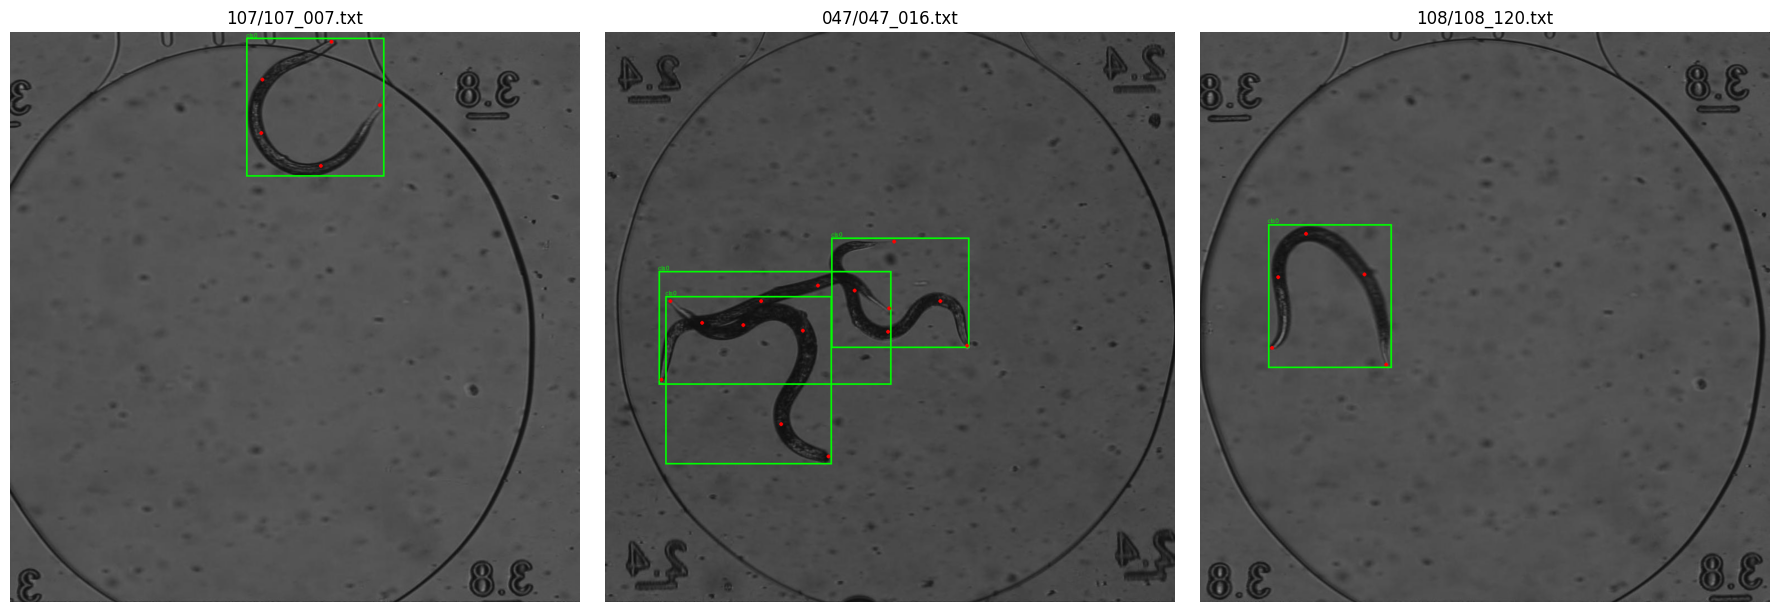

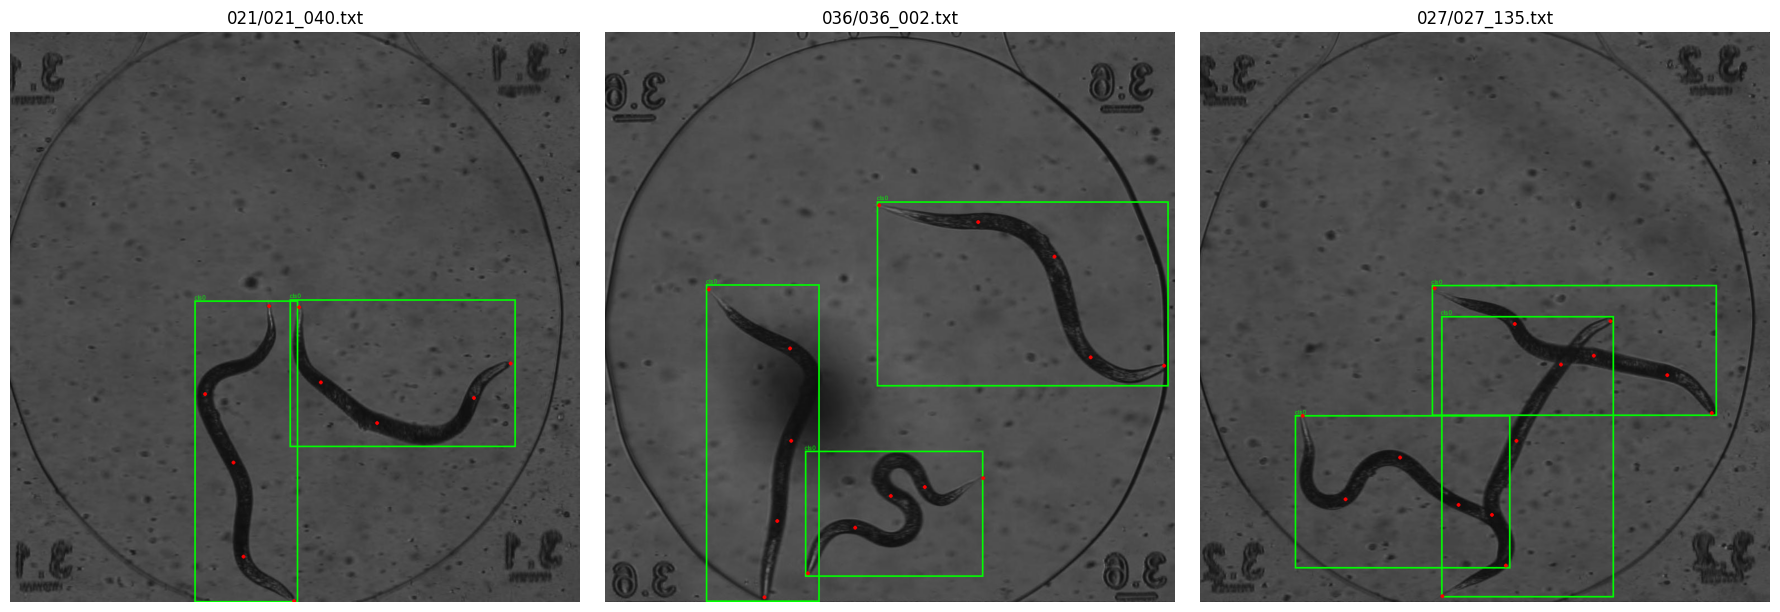

In [36]:
preview_split(train_root, sample_count=3)
preview_split(val_root, sample_count=3)

## Model hosting and finetuning


In [ ]:
from dataclasses import dataclass, field
from ultralytics import YOLO
import yaml, json

#  Détecter le vrai kpt_shape depuis le JSON
with open(TRAIN_JSON_FIXED) as f:
    data = json.load(f)

cat    = data["categories"][0]
N_KPTS = len(cat.get("keypoints", [])) or (len(data["annotations"][0]["keypoints"]) // 3)
print(f"kpt_shape détecté automatiquement : ({N_KPTS}, 3)")

#config
@dataclass(frozen=True)
class TrainingConfig:
    DATASET_YAML : str   = "spaceanimal_c_elegans.yaml"
    MODEL        : str   = "yolov8s-pose.pt"
    EPOCHS       : int   = 50
    KPT_SHAPE    : tuple = field(default_factory=lambda: (N_KPTS, 3))  # ← auto
    PROJECT      : str   = "SpaceAnimal_C_elegans"
    NAME         : str   = "yolov8s-pose_50_epochs"
    CLASSES_DICT : dict  = field(default_factory=lambda: {0: "c_elegans"})

@dataclass(frozen=True)
class DatasetConfig:
    BATCH_SIZE   : int   = 32
    CLOSE_MOSAIC : int   = 10
    MOSAIC       : float = 0.4
    FLIP_LR      : float = 0.0

train_config = TrainingConfig()
data_config  = DatasetConfig()

print(f"KPT_SHAPE final : {train_config.KPT_SHAPE}")
print(f"Modèle          : {train_config.MODEL}")
print(f"Epochs          : {train_config.EPOCHS}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
kpt_shape détecté automatiquement : (5, 3)
KPT_SHAPE final : (5, 3)
Modèle          : yolov8s-pose.pt
Epochs          : 50


In [ ]:
import os

current_dir = os.getcwd()
data_dict = dict(
    path=OUTPUT_DATASET,
    train="train_yolo_pose/images",
    val="val_yolo_pose/images",
    names=train_config.CLASSES_DICT,
    kpt_shape=list(train_config.KPT_SHAPE),
)

with open(train_config.DATASET_YAML, "w") as config_file:
    yaml.safe_dump(data_dict, config_file, sort_keys=False)

print(f"Saved dataset YAML to {train_config.DATASET_YAML}")
print(data_dict)


Saved dataset YAML to spaceanimal_c_elegans.yaml
{'path': '/content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/dataset_c.elegans_yolo', 'train': 'train_yolo_pose/images', 'val': 'val_yolo_pose/images', 'names': {0: 'c_elegans'}, 'kpt_shape': [5, 3]}


In [ ]:
pose_model = YOLO(train_config.MODEL)

pose_model.train(
    data=train_config.DATASET_YAML,
    epochs=train_config.EPOCHS,
    batch=data_config.BATCH_SIZE,
    project=train_config.PROJECT,
    name=train_config.NAME,
    close_mosaic=data_config.CLOSE_MOSAIC,
    mosaic=data_config.MOSAIC,
    fliplr=data_config.FLIP_LR,

    save=True,           # save checkpoints
    save_period=5,       # save every 5 epochs
    resume=False,        # set True if resuming
)


100%|██████████| 22.4M/22.4M [00:00<00:00, 92.6MB/s]


New https://pypi.org/project/ultralytics/8.4.39 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=pose, mode=train, model=yolov8s-pose.pt, data=spaceanimal_c_elegans.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=5, cache=False, device=None, workers=8, project=SpaceAnimal_C_elegans, name=yolov8s-pose_50_epochs, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, 

100%|██████████| 755k/755k [00:00<00:00, 28.2MB/s]


Overriding model.yaml kpt_shape=[17, 3] with kpt_shape=[5, 3]

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


...

                   all       1374       2983      0.925      0.958      0.967      0.878       0.96      0.947      0.969       0.89



50 epochs completed in 2.571 hours.
Optimizer stripped from SpaceAnimal_C_elegans/yolov8s-pose_50_epochs/weights/last.pt, 20.5MB
Optimizer stripped from SpaceAnimal_C_elegans/yolov8s-pose_50_epochs/weights/best.pt, 20.5MB

Validating SpaceAnimal_C_elegans/yolov8s-pose_50_epochs/weights/best.pt...
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-pose summary (fused): 205 layers, 10,115,424 parameters, 0 gradients, 24.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:33<00:00,  1.53s/it]


                   all       1374       2983       0.93      0.961      0.968      0.878      0.962      0.947      0.969      0.891
Speed: 0.2ms preprocess, 6.2ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to SpaceAnimal_C_elegans/yolov8s-pose_50_epochs


ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7db808ebc9e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    

In [ ]:
ckpt_path = os.path.join(train_config.PROJECT, train_config.NAME, "weights", "best.pt")
model_pose = YOLO(ckpt_path)
metrics = model_pose.val()
print(metrics)


Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-pose summary (fused): 205 layers, 10,115,424 parameters, 0 gradients, 24.3 GFLOPs


val: Scanning /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/dataset_c.elegans_yolo/val_yolo_pose/labels/001.cache... 1374 images, 46 backgrounds, 0 corrupt: 100%|██████████| 1374/1374 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 86/86 [00:35<00:00,  2.43it/s]


                   all       1374       2983      0.931      0.961      0.968      0.878      0.961      0.947      0.969      0.891
Speed: 0.3ms preprocess, 10.7ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to runs/pose/val
ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7db80a6ee8a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.02302

In [ ]:
import shutil

# Save weights to Drive so they survive session crash
DRIVE_SAVE = "/content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/saved_weights"
os.makedirs(DRIVE_SAVE, exist_ok=True)

weights_src = os.path.join(train_config.PROJECT, train_config.NAME, "weights")
shutil.copytree(weights_src, os.path.join(DRIVE_SAVE, "weights"), dirs_exist_ok=True)

print(" Weights saved to Drive!")

✅ Weights saved to Drive!


In [ ]:
import os
from ultralytics import YOLO

ckpt_path = os.path.join(train_config.PROJECT, train_config.NAME, "weights", "best.pt")

# Safety check
if not os.path.exists(ckpt_path):
    print(" best.pt not found! Trying last.pt...")
    ckpt_path = os.path.join(train_config.PROJECT, train_config.NAME, "weights", "last.pt")

print(f" Loading: {ckpt_path}")
model_pose = YOLO(ckpt_path)

metrics = model_pose.val(data=train_config.DATASET_YAML)
print(metrics)

✅ Loading: SpaceAnimal_C_elegans/yolov8s-pose_50_epochs/weights/best.pt
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-pose summary (fused): 205 layers, 10,115,424 parameters, 0 gradients, 24.3 GFLOPs


val: Scanning /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/dataset_c.elegans_yolo/val_yolo_pose/labels/001.cache... 1374 images, 46 backgrounds, 0 corrupt: 100%|██████████| 1374/1374 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 86/86 [00:35<00:00,  2.45it/s]


                   all       1374       2983      0.931      0.961      0.968      0.878      0.961      0.947      0.969      0.891
Speed: 0.3ms preprocess, 9.8ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/pose/val2
ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7db808b89f70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.02302

In [ ]:
print("\n RÉSULTATS FINAUX — YOLOv8s-pose C.elegans")
print("=" * 50)
print(f"Box  mAP50    : {metrics.box.map50:.4f}")
print(f"Box  mAP50-95 : {metrics.box.map:.4f}")
print(f"Pose mAP50    : {metrics.pose.map50:.4f}")
print(f"Pose mAP50-95 : {metrics.pose.map:.4f}")
print("=" * 50)


 RÉSULTATS FINAUX — YOLOv8s-pose C.elegans
Box  mAP50    : 0.9681
Box  mAP50-95 : 0.8779
Pose mAP50    : 0.9693
Pose mAP50-95 : 0.8907


In [ ]:
import shutil

DRIVE_SAVE = "/content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/saved_weights"
os.makedirs(DRIVE_SAVE, exist_ok=True)

weights_src = os.path.join(train_config.PROJECT, train_config.NAME, "weights")
shutil.copytree(weights_src, os.path.join(DRIVE_SAVE, "weights"), dirs_exist_ok=True)

print("Weights sauvegardés sur Drive!")
print(f" Path: {DRIVE_SAVE}/weights/")

Weights sauvegardés sur Drive!
 Path: /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/saved_weights/weights/


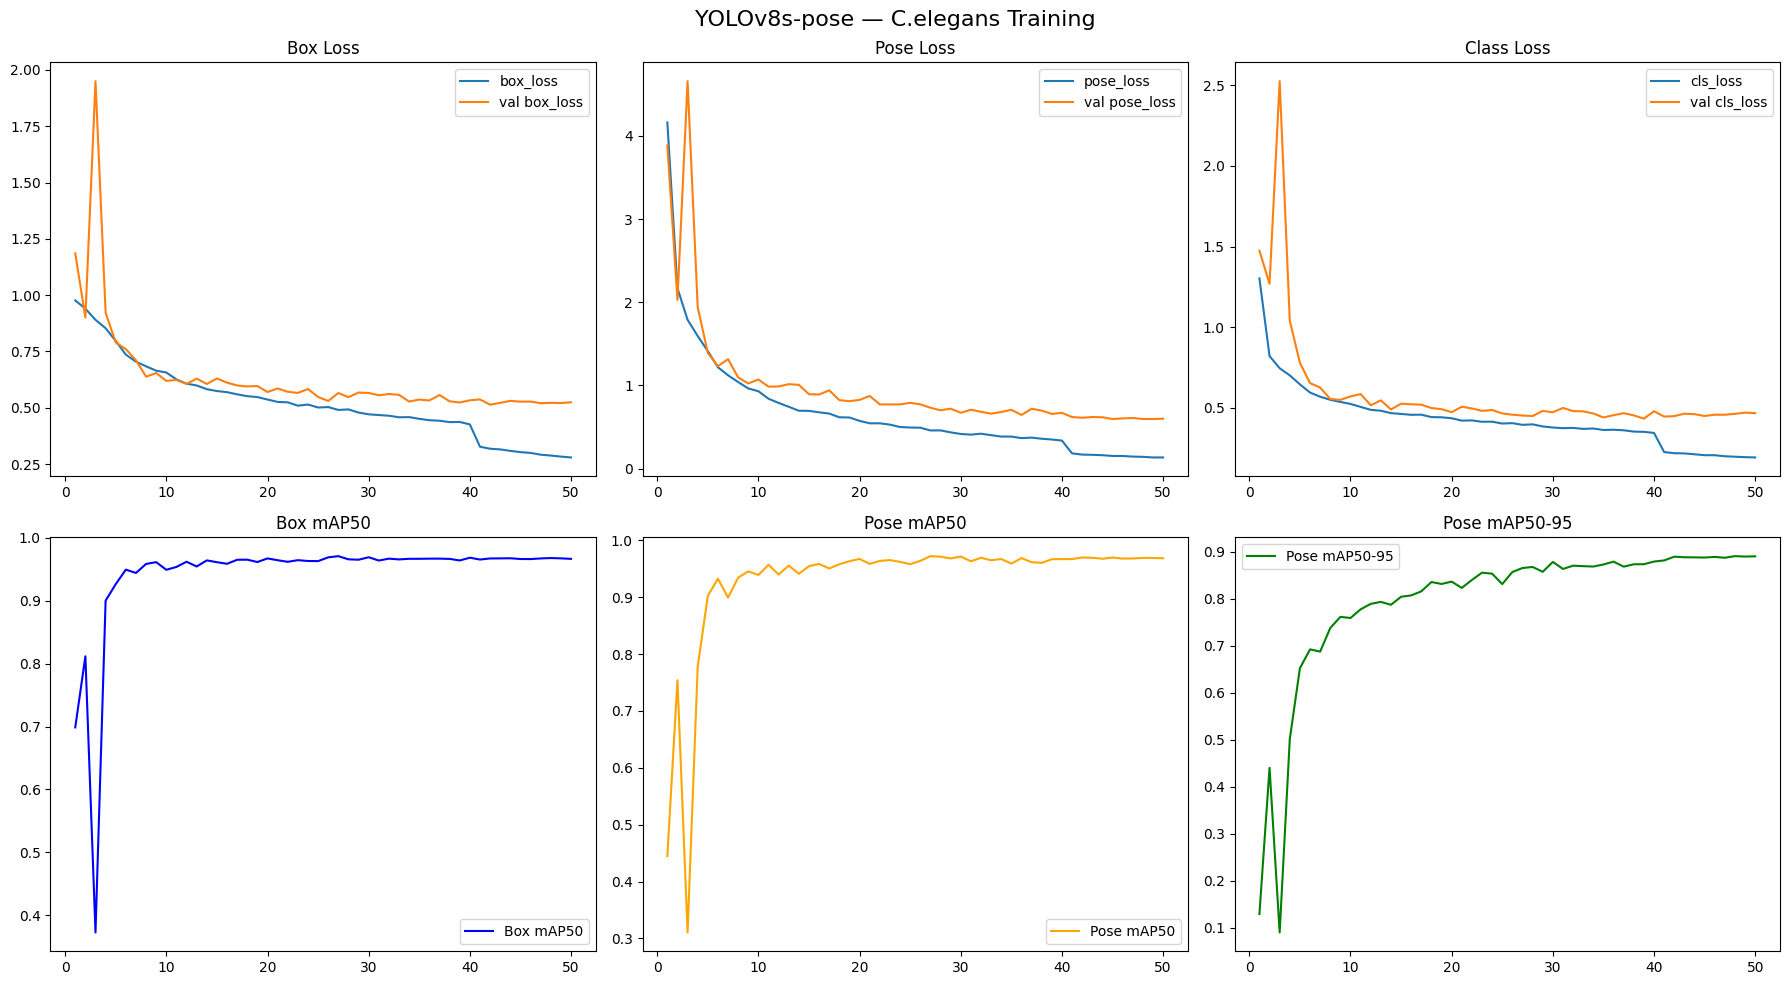

 Courbes sauvegardées → training_curves.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

results_csv = Path(train_config.PROJECT) / train_config.NAME / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("YOLOv8s-pose — C.elegans Training", fontsize=16)

axes[0,0].plot(df["epoch"], df["train/box_loss"], label="box_loss")
axes[0,0].plot(df["epoch"], df["val/box_loss"], label="val box_loss")
axes[0,0].set_title("Box Loss")
axes[0,0].legend()

axes[0,1].plot(df["epoch"], df["train/pose_loss"], label="pose_loss")
axes[0,1].plot(df["epoch"], df["val/pose_loss"], label="val pose_loss")
axes[0,1].set_title("Pose Loss")
axes[0,1].legend()

axes[0,2].plot(df["epoch"], df["train/cls_loss"], label="cls_loss")
axes[0,2].plot(df["epoch"], df["val/cls_loss"], label="val cls_loss")
axes[0,2].set_title("Class Loss")
axes[0,2].legend()

axes[1,0].plot(df["epoch"], df["metrics/mAP50(B)"], label="Box mAP50", color="blue")
axes[1,0].set_title("Box mAP50")
axes[1,0].legend()

axes[1,1].plot(df["epoch"], df["metrics/mAP50(P)"], label="Pose mAP50", color="orange")
axes[1,1].set_title("Pose mAP50")
axes[1,1].legend()

axes[1,2].plot(df["epoch"], df["metrics/mAP50-95(P)"], label="Pose mAP50-95", color="green")
axes[1,2].set_title("Pose mAP50-95")
axes[1,2].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print(" Courbes sauvegardées → training_curves.png")

## Analyse des résultats:
Excellent results. Pose mAP50 of 96.9% and mAP50-95 of 89.1% on C. elegans keypoint detection is state-of-the-art level for a small-to-medium dataset.

The model generalizes well across strict IoU thresholds, indicating high spatial precision on worm body keypoints.


* A pose mAP50-95 of **89.1%** on C. elegans keypoints is genuinely impressive — most published works on animal pose estimation sit well below 80% at strict IoU thresholds.

* The jump from epoch 1 (pose mAP50 = 0.46) to final (0.97) shows the model learned the worm body structure very effectively over 50 epochs. The right call to not cut to 40.



##  Inference et test

In [5]:
from ultralytics import YOLO

ckpt_path = "/content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/saved_weights/weights/best.pt"
model_pose= YOLO(ckpt_path)
print(" Model loaded!")

 Model loaded!


Testing on: /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/dataset_c.elegans_yolo/val_yolo_pose/images/044/044_000.jpg


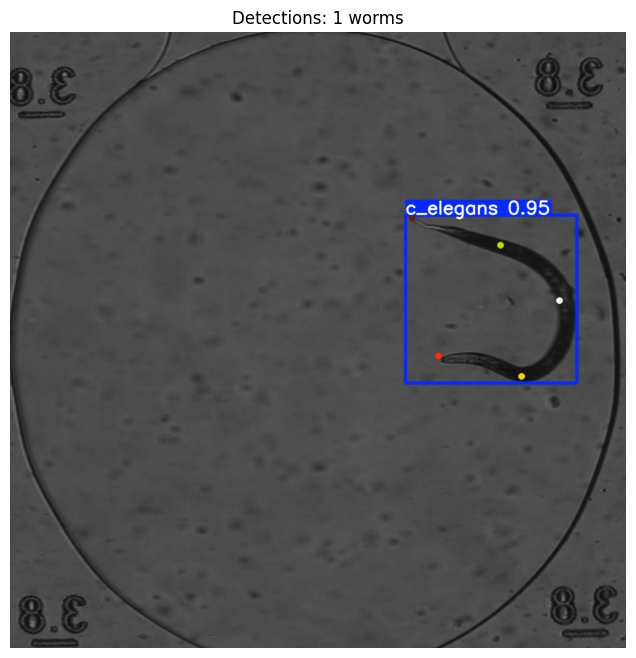

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path
import random

#  Pick image
val_image_list = list(Path(f"{OUTPUT_DATASET}/val_yolo_pose/images").rglob("*.jpg"))
one_image = str(random.choice(val_image_list))
print(f"Testing on: {one_image}")

#  Predict
r = model_pose.predict(
    source=one_image,
    conf=0.25,
    verbose=False
)[0]

# Show
plt.figure(figsize=(8, 8))
plt.imshow(r.plot()[:, :, ::-1])
plt.axis("off")
plt.title(f"Detections: {len(r.boxes)} worms")
plt.show()